# Drug-state prediction: performance, permutation tests, channel subsets

* **Table** full-montage A/B/C performance (per fold + mean), with permutation p-values
* **Table + figure** estimator comparison (random forest vs RBF-SVM vs XGBoost) — shows the null connectivity result is not an artefact of one algorithm
* **Figure** channel-subset performance heatmap (balanced accuracy & ROC-AUC, permutation stars)
* **Figure** per-fold balanced-accuracy strip plot across montages

All models use subject-aware nested cross-validation with 10 outer leave-one-subject-out folds (10 subjects). Reads the cross-validated model outputs in `results/models/` and the permutation summaries in `results/permutation/` (produced by `scripts/03_train_models.py` and `scripts/04_channel_subset_models.py`).

In [1]:
import sys, pathlib
for _cand in (pathlib.Path.cwd(), pathlib.Path.cwd().parent):
    if (_cand / "src" / "ketamine_eeg").exists():
        sys.path.insert(0, str(_cand / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ketamine_eeg import config as c
from ketamine_eeg.plotting import apply_style, fig_width
apply_style()
c.ensure_dirs()
print("ketamine_eeg loaded; figures ->", c.FIGURE_DIR.relative_to(c.PROJECT_ROOT))

ketamine_eeg loaded; figures -> results/figures


In [2]:
full_all = pd.read_csv(c.RESULTS_MAIN_PATH)
sub_all = pd.read_csv(c.RESULTS_SUBSET_PATH)
full_perm_all = pd.read_csv(c.PERM_SUMMARY_MAIN_PATH)
sub_perm_all = pd.read_csv(c.PERM_SUMMARY_SUBSET_PATH)

# Results now span three estimators (rf/svm/xgb). The main-narrative table and
# figures use one estimator (random forest); the estimator comparison further
# down shows all three side by side.
HERO = "rf"
full = full_all[full_all["estimator"] == HERO].copy()
sub = sub_all[sub_all["estimator"] == HERO].copy()
full_perm = full_perm_all[full_perm_all["estimator"] == HERO].set_index("model")
sub_perm = sub_perm_all[sub_perm_all["estimator"] == HERO].copy()

print("estimators:", sorted(full_all["estimator"].unique()))
print("models:", sorted(full["model"].unique()))
print("subsets:", sorted(sub["subset"].unique()))
print("outer folds:", full["fold"].nunique(), "(leave-one-subject-out)")

estimators: ['rf', 'svm', 'xgb']
models: ['A_bandpower_epoch', 'B_wpli_edges_epoch_sliding', 'C_AplusB_epoch_sliding']
subsets: ['bis_quatro', 'both_lateral', 'left_lateral', 'right_lateral']
outer folds: 10 (leave-one-subject-out)


## Table: full-montage A/B/C performance (random forest)
Mean +/- SD balanced accuracy, ROC-AUC and accuracy across the 10 outer leave-one-subject-out folds, with centred two-sided permutation p-values. Random forest is the main-narrative estimator; the estimator comparison below reports SVM and XGBoost too. Saved to `results/tables/main_model_performance.csv`.

In [3]:
label = {c.MODEL_A: "A bandpower (24)", c.MODEL_B: "B wPLI (5673)", c.MODEL_C: "C A+B (5697)"}
rows = []
for m in (c.MODEL_A, c.MODEL_B, c.MODEL_C):
    g = full[full["model"] == m]
    pr = full_perm.loc[m]
    rows.append({
        "model": label[m],
        "bacc_mean": g["balanced_accuracy"].mean(), "bacc_sd": g["balanced_accuracy"].std(),
        "auc_mean": g["roc_auc"].mean(), "auc_sd": g["roc_auc"].std(),
        "acc_mean": g["accuracy"].mean(),
        "p_perm_bacc": float(pr["p_perm_bacc"]), "p_perm_auc": float(pr["p_perm_auc"]),
    })
perf = pd.DataFrame(rows)
perf.to_csv(c.TABLES_DIR / "main_model_performance.csv", index=False)
print("saved results/tables/main_model_performance.csv")
perf.round(4)

saved results/tables/main_model_performance.csv


,model,bacc_mean,bacc_sd,auc_mean,auc_sd,acc_mean,p_perm_bacc,p_perm_auc
0,A bandpower (24),0.7071,0.1908,0.8031,0.2694,0.7054,0.0110,0.0100
1,B wPLI (5673),0.4740,0.1651,0.4886,0.2017,0.4669,0.5634,0.8531
2,C A+B (5697),0.6713,0.0969,0.8200,0.0676,0.6755,0.0120,0.0020


## Table + figure: estimator comparison (is the null an RF artefact?)
The same full-montage A/B/C feature sets, classified by all three estimators (random forest, RBF-SVM, XGBoost). The representation is held constant (shared PCA(100) for the wPLI sets B/C), so only the classifier changes. If connectivity (B) stays at chance for *every* estimator while power (A) decodes for *every* estimator, the null connectivity result cannot be blamed on the choice of random forest. Full-montage numbers are saved to `results/tables/model_performance_by_estimator.csv`; the analogous channel-subset table is saved to `results/tables/subset_performance_by_estimator.csv`.

In [4]:
model_order = [c.MODEL_A, c.MODEL_B, c.MODEL_C]
model_short = {c.MODEL_A: "A power (24)", c.MODEL_B: "B wPLI (5673)", c.MODEL_C: "C A+B (5697)"}

def _est_rows(res_df, perm_df, group_keys, group_vals):
    """Mean +/- SD metrics + permutation p per estimator for one (model[/subset/feat]) cell."""
    g = res_df
    p = perm_df
    for k, v in zip(group_keys, group_vals):
        g = g[g[k] == v]; p = p[p[k] == v]
    return {"bacc_mean": g["balanced_accuracy"].mean(), "bacc_sd": g["balanced_accuracy"].std(),
            "auc_mean": g["roc_auc"].mean(), "auc_sd": g["roc_auc"].std(),
            "p_perm_bacc": float(p["p_perm_bacc"].iloc[0]) if len(p) else np.nan,
            "p_perm_auc": float(p["p_perm_auc"].iloc[0]) if len(p) else np.nan}

# --- full montage: estimator x feature set --------------------------------------
rows = []
for est in c.ESTIMATORS:
    for m in model_order:
        r = _est_rows(full_all[full_all.estimator == est],
                      full_perm_all[full_perm_all.estimator == est], ["model"], [m])
        rows.append({"estimator": c.ESTIMATOR_LABELS[est], "model": model_short[m], **r})
by_est = pd.DataFrame(rows)
by_est.to_csv(c.TABLES_DIR / "model_performance_by_estimator.csv", index=False)

# --- channel subsets: estimator x subset x feature set --------------------------
sub_rows = []
for est in c.ESTIMATORS:
    for s in sorted(sub_all["subset"].unique()):
        for ft in ("A", "B", "C"):
            r = _est_rows(sub_all[sub_all.estimator == est],
                          sub_perm_all[sub_perm_all.estimator == est],
                          ["subset", "feat_type"], [s, ft])
            sub_rows.append({"estimator": c.ESTIMATOR_LABELS[est], "subset": s,
                             "feat_type": ft, **r})
by_est_sub = pd.DataFrame(sub_rows)
by_est_sub.to_csv(c.TABLES_DIR / "subset_performance_by_estimator.csv", index=False)

print("saved model_performance_by_estimator.csv + subset_performance_by_estimator.csv")
by_est.round(4)

saved model_performance_by_estimator.csv + subset_performance_by_estimator.csv


,estimator,model,bacc_mean,bacc_sd,auc_mean,auc_sd,p_perm_bacc,p_perm_auc
0,Random forest,A power (24),0.7071,0.1908,0.8031,0.2694,0.0110,0.0100
1,Random forest,B wPLI (5673),0.4740,0.1651,0.4886,0.2017,0.5634,0.8531
2,Random forest,C A+B (5697),0.6713,0.0969,0.8200,0.0676,0.0120,0.0020
3,SVM (RBF),A power (24),0.7203,0.1871,0.8496,0.1992,0.0070,0.0160
4,SVM (RBF),B wPLI (5673),0.5339,0.1092,0.5780,0.1628,0.4486,0.2647
5,SVM (RBF),C A+B (5697),0.5889,0.1254,0.6171,0.1607,0.0480,0.0939
6,XGBoost,A power (24),0.7128,0.2105,0.8486,0.2222,0.0120,0.0070
7,XGBoost,B wPLI (5673),0.5196,0.1575,0.4965,0.1713,0.6284,0.9411
8,XGBoost,C A+B (5697),0.6522,0.1115,0.7578,0.1253,0.0100,0.0020


saved estimator_comparison_bacc.png/.pdf


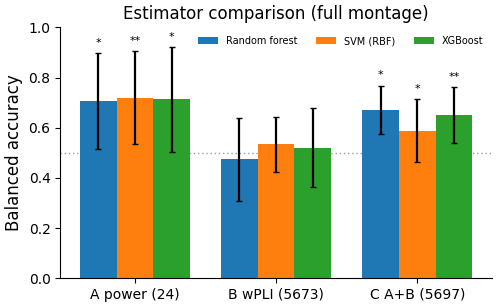

In [5]:
# Grouped bars: balanced accuracy per feature set, one bar per estimator.
def _star(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

fig, ax = plt.subplots(figsize=(fig_width("single"), 3.3))
x = np.arange(len(model_order)); w = 0.26
for j, est in enumerate(c.ESTIMATORS):
    means, sds, ps = [], [], []
    for m in model_order:
        g = full_all[(full_all.estimator == est) & (full_all.model == m)]
        pr = full_perm_all[(full_perm_all.estimator == est) & (full_perm_all.model == m)]
        means.append(g["balanced_accuracy"].mean()); sds.append(g["balanced_accuracy"].std())
        ps.append(float(pr["p_perm_bacc"].iloc[0]) if len(pr) else np.nan)
    off = (j - 1) * w
    bars = ax.bar(x + off, means, w, yerr=sds, capsize=2, label=c.ESTIMATOR_LABELS[est])
    for xi, (mv, sd, p) in enumerate(zip(means, sds, ps)):
        if _star(p):
            ax.text(x[xi] + off, mv + sd + 0.02, _star(p), ha="center", va="bottom", fontsize=8)

ax.axhline(0.5, ls=(0, (1, 2)), color="0.6", lw=1, zorder=0)   # chance
ax.set_xticks(x); ax.set_xticklabels([model_short[m] for m in model_order])
ax.set_ylabel("Balanced accuracy"); ax.set_ylim(0.0, 1.0)
ax.set_title("Estimator comparison (full montage)")
ax.legend(fontsize=7, frameon=False, ncol=3, loc="upper right")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "estimator_comparison_bacc.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "estimator_comparison_bacc.pdf", bbox_inches="tight")
print("saved estimator_comparison_bacc.png/.pdf")
plt.show()

## Table: sensitivity / specificity per classifier
Operating-point sensitivity (ketamine detection rate, TP/(TP+FN)) and specificity (awake correct rate, TN/(TN+FP)), computed per LOSO fold from the confusion counts and averaged over folds, for every estimator × montage × feature set. Because each leave-one-subject-out fold contains one awake *and* one ketamine recording, both are defined per fold and `(sensitivity + specificity) / 2` reproduces the reported balanced accuracy. Saved to `results/tables/sensitivity_specificity_by_estimator.csv`.

In [6]:
# Per-fold sensitivity / specificity from the confusion counts, averaged over folds.
def _fold_sens_spec(g):
    se = g["tp"] / (g["tp"] + g["fn"])          # sensitivity: ketamine detection (positive class = 1)
    sp = g["tn"] / (g["tn"] + g["fp"])          # specificity: awake correct (negative class = 0)
    return pd.Series({"sensitivity": se.mean(), "sens_sd": se.std(),
                      "specificity": sp.mean(), "spec_sd": sp.std(),
                      "balanced_accuracy": g["balanced_accuracy"].mean(), "n_folds": int(len(g))})

_m2ft = {c.MODEL_A: "A", c.MODEL_B: "B", c.MODEL_C: "C"}
_fm = (full_all.groupby(["estimator", "model"])
       .apply(_fold_sens_spec, include_groups=False).reset_index())
_fm["montage"] = "full_62ch"
_fm["feat_type"] = _fm["model"].map(_m2ft)
_sm = (sub_all.groupby(["estimator", "subset", "feat_type"])
       .apply(_fold_sens_spec, include_groups=False).reset_index()
       .rename(columns={"subset": "montage"}))

_cols = ["estimator", "montage", "feat_type", "sensitivity", "sens_sd",
         "specificity", "spec_sd", "balanced_accuracy", "n_folds"]
sens_spec = pd.concat([_fm[_cols], _sm[_cols]], ignore_index=True)
sens_spec["estimator"] = sens_spec["estimator"].map(c.ESTIMATOR_LABELS)
sens_spec.to_csv(c.TABLES_DIR / "sensitivity_specificity_by_estimator.csv", index=False)
print("saved results/tables/sensitivity_specificity_by_estimator.csv  (rows:", len(sens_spec), ")")

# quick view: full montage + the two sparse lateral montages, feature set A (power)
_view = sens_spec[(sens_spec.feat_type == "A") &
                  (sens_spec.montage.isin(["full_62ch", "both_lateral", "left_lateral"]))]
_view[["estimator", "montage", "sensitivity", "specificity", "balanced_accuracy"]].round(3)

saved results/tables/sensitivity_specificity_by_estimator.csv  (rows: 45 )


,estimator,montage,sensitivity,specificity,balanced_accuracy
0,Random forest,full_62ch,0.646,0.768,0.707
3,SVM (RBF),full_62ch,0.689,0.752,0.720
6,XGBoost,full_62ch,0.717,0.708,0.713
12,Random forest,both_lateral,0.775,0.710,0.742
15,Random forest,left_lateral,0.733,0.764,0.748
24,SVM (RBF),both_lateral,0.643,0.678,0.661
27,SVM (RBF),left_lateral,0.636,0.681,0.659
36,XGBoost,both_lateral,0.671,0.672,0.671
39,XGBoost,left_lateral,0.664,0.713,0.688


## Figure: channel-subset performance heatmap
Full 62-channel montage vs reduced montages, for feature sets A/B/C. Stars are metric-matched two-sided permutation tests (\*\*\* p<0.001, \*\* p<0.01, \* p<0.05).

saved channel_subsets_heatmap.png (+ _notitle)


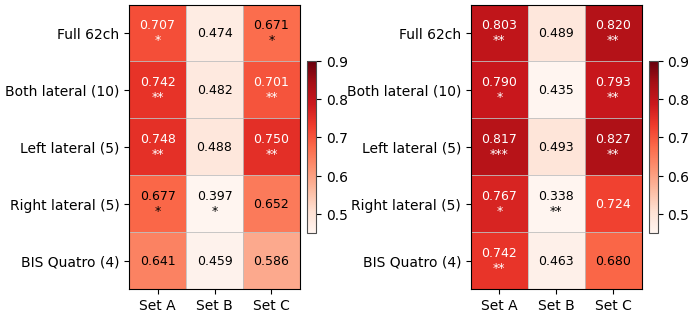

In [7]:
subsets = ["full_62ch", "both_lateral", "left_lateral", "right_lateral", "bis_quatro"]
heat_labels = ["Full 62ch", "Both lateral (10)", "Left lateral (5)", "Right lateral (5)", "BIS Quatro (4)"]
feat_types = ["A", "B", "C"]

def stars(p):
    if pd.isna(p): return ""
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""

bacc = np.full((len(subsets), 3), np.nan); auc = np.full((len(subsets), 3), np.nan)
pb = np.full((len(subsets), 3), np.nan); pa = np.full((len(subsets), 3), np.nan)
for ci, ft in enumerate(feat_types):
    for ri, s in enumerate(subsets):
        if s == "full_62ch":
            g = full[full["model"] == c.FULL_MODEL_MAP[ft]]
            bacc[ri, ci] = g["balanced_accuracy"].mean(); auc[ri, ci] = g["roc_auc"].mean()
            pr = full_perm.loc[c.FULL_MODEL_MAP[ft]]
            pb[ri, ci] = float(pr["p_perm_bacc"]); pa[ri, ci] = float(pr["p_perm_auc"])
        else:
            g = sub[(sub["subset"] == s) & (sub["feat_type"] == ft)]
            bacc[ri, ci] = g["balanced_accuracy"].mean(); auc[ri, ci] = g["roc_auc"].mean()
            pr = sub_perm[(sub_perm["subset"] == s) & (sub_perm["feat_type"] == ft)]
            if len(pr):
                pb[ri, ci] = float(pr["p_perm_bacc"].values[0]); pa[ri, ci] = float(pr["p_perm_auc"].values[0])

# Sequential white-to-red colormap (colour-blind safe; avoids red-green, all values positive).
# aspect="equal" -> square tiles; figsize tuned so the two square-tile panels pack without a
# wide colorbar gap (bbox_inches="tight" crops the outer margins on save).
fig, axes = plt.subplots(1, 2, figsize=(7.0, 4.5))
titles = ["Balanced accuracy", "ROC-AUC"]
for ax, mat, pmat, title in [(axes[0], bacc, pb, titles[0]), (axes[1], auc, pa, titles[1])]:
    im = ax.imshow(mat, vmin=0.45, vmax=0.90, cmap="Reds", aspect="equal")
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.outline.set_edgecolor("0.3"); cb.outline.set_linewidth(0.8)
    ax.set_title(title)
    ax.set_xticks(range(3)); ax.set_xticklabels([f"Set {f}" for f in feat_types])
    ax.set_yticks(range(len(subsets))); ax.set_yticklabels(heat_labels)
    # thin gridlines on cell boundaries so every cell is delineated regardless of fill
    ax.set_xticks(np.arange(-0.5, len(feat_types), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(subsets), 1), minor=True)
    ax.grid(which="minor", color="0.75", linewidth=0.6)
    ax.tick_params(which="minor", length=0)
    for ri in range(mat.shape[0]):
        for ci in range(mat.shape[1]):
            lab = f"{mat[ri,ci]:.3f}" + (f"\n{stars(pmat[ri,ci])}" if stars(pmat[ri,ci]) else "")
            rr, gg, bb, _ = im.cmap(im.norm(mat[ri, ci]))   # cell colour -> readable text
            lum = 0.299*rr + 0.587*gg + 0.114*bb
            ax.text(ci, ri, lab, ha="center", va="center", fontsize=9,
                    color="white" if lum < 0.55 else "black")
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "channel_subsets_heatmap.png", dpi=300, bbox_inches="tight")
# title-free version (panel metric supplied by the figure caption) for manuscript/poster use
for ax in axes:
    ax.set_title("")
fig.savefig(c.FIGURE_DIR / "channel_subsets_heatmap_notitle.png", dpi=300, bbox_inches="tight")
print("saved channel_subsets_heatmap.png (+ _notitle)")
plt.show()

## Figure: per-fold balanced accuracy across montages

saved channel_subsets_per_fold.png


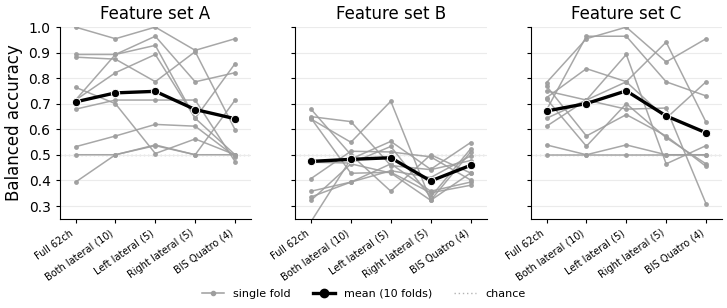

In [8]:
from matplotlib.lines import Line2D

# Per-fold balanced accuracy across montages. The same nested-CV splits are reused
# for every montage, so a given fold = the same held-out subject everywhere (10
# outer leave-one-subject-out folds); each fold is a grey line across montages and
# the black line is the 10-fold mean. Random-forest estimator (HERO).
# Square panels (set_box_aspect), de-spined, faint y-grid, shared legend below.
fold_ids = sorted(full["fold"].unique())

def _bacc_by_fold(ft, s):
    if s == "full_62ch":
        d = full[full["model"] == c.FULL_MODEL_MAP[ft]]
    else:
        d = sub[(sub["subset"] == s) & (sub["feat_type"] == ft)]
    return d.set_index("fold")["balanced_accuracy"]

fig, axes = plt.subplots(1, 3, figsize=(fig_width("double"), 3.4), sharey=True)
xpos = np.arange(len(subsets))
for ax, ft in zip(axes, feat_types):
    series = [_bacc_by_fold(ft, s) for s in subsets]
    ax.axhline(0.5, ls=(0, (1, 2)), color="0.7", lw=1, zorder=1)            # chance
    for f in fold_ids:                                                      # one line per fold
        yv = [series[m].get(f, np.nan) for m in range(len(subsets))]
        ax.plot(xpos, yv, "-", color="0.62", lw=1.1, alpha=0.9, zorder=2)
        ax.plot(xpos, yv, ".", color="0.62", ms=5, alpha=0.9, zorder=2)
    means = [float(series[m].mean()) for m in range(len(subsets))]
    ax.plot(xpos, means, "-o", color="black", lw=2.4, ms=6, zorder=4,
            markeredgecolor="white", markeredgewidth=0.7)
    ax.set_box_aspect(1)                                                    # square canvas
    ax.set_title(f"Feature set {ft}", pad=6)
    ax.set_xticks(xpos); ax.set_xticklabels(heat_labels, fontsize=7, rotation=35, ha="right")
    ax.set_ylim(0.25, 1.0); ax.set_xlim(-0.4, len(subsets) - 0.6)
    ax.set_yticks(np.arange(0.3, 1.01, 0.1))
    ax.grid(axis="y", color="0.92", lw=0.8, zorder=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.tick_params(length=3)
axes[0].set_ylabel("Balanced accuracy")
handles = [Line2D([0], [0], color="0.62", lw=1.1, marker=".", ms=6, label="single fold"),
           Line2D([0], [0], color="black", lw=2.4, marker="o", ms=6, label="mean (10 folds)"),
           Line2D([0], [0], color="0.7", lw=1, ls=(0, (1, 2)), label="chance")]
fig.legend(handles=handles, fontsize=8, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "channel_subsets_per_fold.png", dpi=300, bbox_inches="tight")
print("saved channel_subsets_per_fold.png")
plt.show()

## Figure: per-subject balanced accuracy (LOSO) — full montage × 3 classifiers
Under leave-one-subject-out CV each outer fold holds out exactly one subject, so every fold is a per-subject test. This panel plots each held-out subject's balanced accuracy for feature sets A/B/C, one marker per estimator (RF / SVM / XGB), sorted by the RF set-A value. It shows which subjects the power model fails on and whether those failures are shared across classifiers (subject-driven) or algorithm-specific. Saved to `results/figures/per_subject_bacc.png/.pdf`.

saved per_subject_bacc.png/.pdf


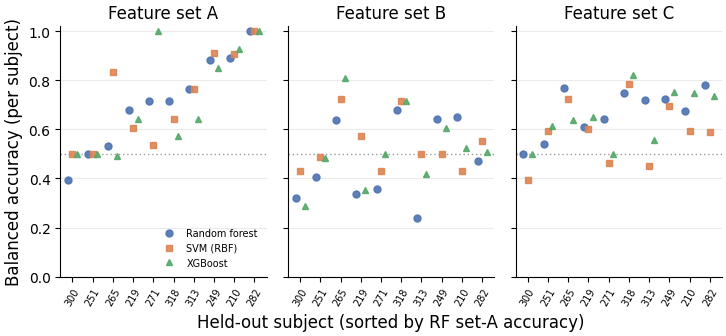

In [9]:
# Per-subject balanced accuracy under LOSO (fold == held-out subject), full montage.
preds_full = pd.read_csv(c.PREDS_MAIN_PATH)

def _subj_bacc(g):
    yt, yp = g["y_true"].values, g["y_pred"].values
    tp = ((yt == 1) & (yp == 1)).sum(); fn = ((yt == 1) & (yp == 0)).sum()
    tn = ((yt == 0) & (yp == 0)).sum(); fp = ((yt == 0) & (yp == 1)).sum()
    se = tp / (tp + fn) if (tp + fn) else np.nan
    sp = tn / (tn + fp) if (tn + fp) else np.nan
    return np.nanmean([se, sp])

psb = (preds_full.groupby(["estimator", "model", "subject_id"])
       .apply(_subj_bacc, include_groups=False).rename("bacc").reset_index())

# fixed subject order across panels: ascending RF set-A balanced accuracy (failures first)
order = (psb[(psb.estimator == "rf") & (psb.model == c.MODEL_A)]
         .sort_values("bacc")["subject_id"].tolist())
xpos = {s: i for i, s in enumerate(order)}
feat_models = [("A", c.MODEL_A), ("B", c.MODEL_B), ("C", c.MODEL_C)]
est_style = {"rf": ("#4C72B0", "o"), "svm": ("#DD8452", "s"), "xgb": ("#55A868", "^")}
dodge = {"rf": -0.22, "svm": 0.0, "xgb": 0.22}

fig, axes = plt.subplots(1, 3, figsize=(fig_width("double"), 3.6), sharey=True)
for ax, (ft, mod) in zip(axes, feat_models):
    ax.axhline(0.5, ls=(0, (1, 2)), color="0.6", lw=1, zorder=1)          # chance
    for est, (col, mk) in est_style.items():
        d = psb[(psb.estimator == est) & (psb.model == mod)].set_index("subject_id")
        xs = [xpos[s] + dodge[est] for s in order]
        ys = [d.loc[s, "bacc"] for s in order]
        ax.plot(xs, ys, mk, color=col, ms=5, alpha=0.9, ls="none",
                label=c.ESTIMATOR_LABELS[est], zorder=3)
    ax.set_title(f"Feature set {ft}", pad=6)
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, fontsize=7, rotation=60)
    ax.set_ylim(0, 1.02); ax.set_xlim(-0.6, len(order) - 0.4)
    ax.set_yticks(np.arange(0, 1.01, 0.2))
    ax.grid(axis="y", color="0.92", lw=0.8, zorder=0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[0].set_ylabel("Balanced accuracy (per subject)")
axes[1].set_xlabel("Held-out subject (sorted by RF set-A accuracy)")
axes[0].legend(fontsize=7, frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(c.FIGURE_DIR / "per_subject_bacc.png", dpi=300, bbox_inches="tight")
fig.savefig(c.FIGURE_DIR / "per_subject_bacc.pdf", bbox_inches="tight")
print("saved per_subject_bacc.png/.pdf")
plt.show()